In [ ]:
#!pip install yfinance
# Thêm các thư viện cần thiết
import pandas as pd
from pandas_datareader import data as pdr
import numpy as np
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from tensorflow.keras.models import Model
from keras.layers import LSTM, Dense, Bidirectional, Dropout, Input, Concatenate
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import History
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Activation
from keras.layers import Conv1D, MaxPooling1D, Flatten, AveragePooling1D
!pip install keras-self-attention
from keras_self_attention import SeqSelfAttention
from tensorflow.keras.layers import MultiHeadAttention
!pip install attention
from attention import Attention

  Preparing metadata (setup.py) ... done
  Created wheel for keras-self-attention: filename=keras_self_attention-0.51.0-py3-none-any.whl size=18894 sha256=633aa00719dec0ded453cfc76e41b2be98cf86849018a2be49dce8d592714fba
  Stored in directory: /root/.cache/pip/wheels/b8/f7/24/607b483144fb9c47b4ba2c5fba6b68e54aeee2d5bf6c05302e
Successfully built keras-self-attention


In [ ]:
data_ORCL = pd.read_csv('ORCL.csv')

data_ORCL

,Date,Close,Open,High,Low,Adj Close,Volume,MACD,MFI,RSI,ATR
0,2019-12-31,52.980000,52.570000,53.000000,52.549999,49.294575,7094500,-0.658542,47.794937,37.311870,0.725588
1,2020-01-02,53.950001,53.270000,53.959999,53.230000,50.197102,13899600,-0.584446,48.129089,47.035337,0.743761
2,2020-01-03,53.759998,52.990002,54.049999,52.950001,50.020325,11026700,-0.534891,40.548907,45.545121,0.769206
3,2020-01-06,54.040001,53.360001,54.200001,53.349998,50.280849,10982400,-0.467633,49.636393,48.152135,0.774977
4,2020-01-07,54.160000,53.889999,54.330002,53.610001,50.392494,12015400,-0.400036,59.595826,49.272981,0.771050
...,...,...,...,...,...,...,...,...,...,...,...
1105,2024-05-22,124.599998,124.629997,125.160004,123.300003,124.599998,5705000,1.417709,74.905685,67.306719,2.117463
1106,2024-05-23,124.089996,126.550003,126.699997,123.160004,124.089996,6108600,1.523661,75.480460,64.825717,2.219072
1107,2024-05-24,122.910004,123.419998,123.510002,121.419998,122.910004,7166100,1.495178,67.691852,59.372577,2.251281
1108,2024-05-28,124.489998,123.239998,124.820000,123.010002,124.489998,6911400,1.581862,67.981634,63.767565,2.226904


In [ ]:
data = data_ORCL
epoch = 500
#columns = ['Close']
columns = ['Close', 'Open', 'High', 'Low']
#columns = ['Close', 'MACD', 'MFI', 'RSI', 'ATR']
#columns = ['Close', 'Open', 'High', 'Low', 'Volume', 'MACD', 'MFI', 'RSI', 'ATR']
#columns = ['Close', 'Open', 'High', 'Low', 'Volume', 'MACD', 'MFI', 'RSI', 'ATR', 'USD/VND', 'IR', 'CFI', 'Broad money M2']
#columns = ['Close', 'Open', 'High', 'Low', 'Volume', 'MACD', 'MFI', 'RSI', 'ATR', 'USD/VND', 'IR', 'CFI']

data = data[columns]

train_size = int(len(data) * 0.9)

train = data[:train_size]
test = data['Close']
test = data[train_size:]

train = train[columns]

scaler = MinMaxScaler(feature_range = (0, 1))

# train_scaled = scaler.fit_transform(train)
# test_scaled = scaler.transform(data)
scaled = scaler.fit_transform(data)
train_scaled = scaled[:int(train_size)]

test_data_lb_7day = scaled[int(train_size) - 7: , :]
test_data_lb_14day = scaled[int(train_size) - 14: , :]
test_data_lb_21day = scaled[int(train_size) - 21: , :]

In [ ]:
def create_lstm_parallel(input_layer, units, dropout_rate):
    lstm = LSTM(units=units, return_sequences=True)(input_layer)

    #lstm = Dropout(dropout_rate)(lstm)



    #lstm = SeqSelfAttention(attention_activation='elu')(lstm)
    #lstm = MultiHeadAttention(num_heads=16, key_dim=units)(lstm, lstm)
    lstm = Attention(units=units)(lstm)


    #lstm = Flatten()(lstm)

    #lstm = Dense(units=units, activation='sigmoid')(lstm)

    return lstm

def parallel_lstm_model(train_scaled, test_scaled, lb, batchsize):
    X_train = []
    Y_train = []

    for i in range(lb, len(train_scaled)):
      X_train.append(train_scaled[i - lb:i, :])
      Y_train.append(train_scaled[i, 0])

    X_train, Y_train = np.array(X_train), np.array(Y_train)
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], len(columns)))
    x_train, x_val, y_train, y_val = train_test_split(X_train, Y_train, test_size = 0.1)

    print(x_train.shape)
    print(x_val.shape)
    history = History()
    # Create callback EarlyStopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

    start_time = time.time()

    input_layer = Input(shape=(x_train.shape[1], x_train.shape[2]))

    lstm1 = create_lstm_parallel(input_layer, units=128, dropout_rate=0.3)
    lstm2 = create_lstm_parallel(input_layer, units=128, dropout_rate=0.3)

    concatenated = Concatenate()([lstm1, lstm2])

    concatenated = Flatten()(concatenated)

    dense = Dense(units=128, activation='sigmoid')(concatenated)
    output = Dense(units=1)(concatenated)

    model = Model(inputs=input_layer, outputs=output)

    # Compile the model
    model.compile(optimizer='adam', loss='mse')
    # Train the model
    model.fit(x_train, y_train, epochs=epoch, validation_data=(x_val, y_val),
              batch_size=batchsize, callbacks=[history,early_stopping])

    end_time = time.time()
    training_time = end_time - start_time

    loss = history.history['loss']
    val_loss = history.history['val_loss']
    plt.plot(loss)
    plt.plot(val_loss)
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(['Train', 'Validation'], loc = 'upper right')
    plt.show()

    x_test = []
    for i in range(lb, len(test_scaled)):
      x_test.append(test_scaled[i - lb:i, :])
    x_test = np.array(x_test)
    x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], len(columns)))

    predictions = model.predict(x_test)
    predictions = predictions.reshape(-1, 1)
    X = np.random.rand(int(len(test)), int(len(columns) - 1))
    predictions = np.hstack((predictions, X))
    predictions = scaler.inverse_transform(predictions)

    return predictions[:, 0], training_time

(892, 7, 5)
(100, 7, 5)
Epoch 1/500
14/14 [==============================] - 7s 72ms/step - loss: 0.0589 - val_loss: 0.0258
Epoch 2/500
14/14 [==============================] - 0s 9ms/step - loss: 0.0067 - val_loss: 9.3669e-04
Epoch 3/500
14/14 [==============================] - 0s 10ms/step - loss: 0.0018 - val_loss: 0.0016
Epoch 4/500
14/14 [==============================] - 0s 9ms/step - loss: 0.0011 - val_loss: 0.0010
Epoch 5/500
14/14 [==============================] - 0s 10ms/step - loss: 7.7962e-04 - val_loss: 9.3430e-04
Epoch 6/500
14/14 [==============================] - 0s 10ms/step - loss: 7.6190e-04 - val_loss: 8.8894e-04
Epoch 7/500
14/14 [==============================] - 0s 11ms/step - loss: 7.6046e-04 - val_loss: 8.6608e-04
Epoch 8/500
14/14 [==============================] - 0s 11ms/step - loss: 7.4436e-04 - val_loss: 8.7817e-04
Epoch 9/500
14/14 [==============================] - 0s 9ms/step - loss: 7.3825e-04 - val_loss: 9.0017e-04
Epoch 10/500
14/14 [===============

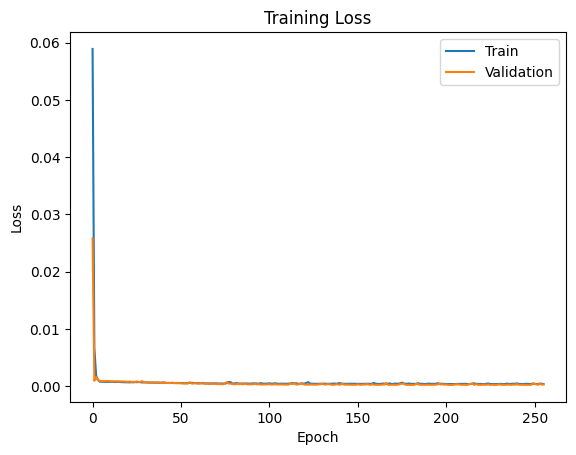

4/4 [==============================] - 2s 5ms/step


In [ ]:
predictions_lb_7day, training_time_lb_7day = parallel_lstm_model(train_scaled, test_data_lb_7day, 7, 64)

(886, 14, 5)
(99, 14, 5)
Epoch 1/500
10/10 [==============================] - 6s 159ms/step - loss: 0.0805 - val_loss: 0.0321
Epoch 2/500
10/10 [==============================] - 0s 13ms/step - loss: 0.0145 - val_loss: 0.0134
Epoch 3/500
10/10 [==============================] - 0s 13ms/step - loss: 0.0053 - val_loss: 0.0042
Epoch 4/500
10/10 [==============================] - 0s 13ms/step - loss: 0.0025 - val_loss: 0.0028
Epoch 5/500
10/10 [==============================] - 0s 12ms/step - loss: 0.0015 - val_loss: 0.0012
Epoch 6/500
10/10 [==============================] - 0s 11ms/step - loss: 0.0011 - val_loss: 0.0013
Epoch 7/500
10/10 [==============================] - 0s 15ms/step - loss: 9.8774e-04 - val_loss: 9.9457e-04
Epoch 8/500
10/10 [==============================] - 0s 12ms/step - loss: 9.5354e-04 - val_loss: 0.0011
Epoch 9/500
10/10 [==============================] - 0s 16ms/step - loss: 9.2653e-04 - val_loss: 9.7146e-04
Epoch 10/500
10/10 [==============================] - 

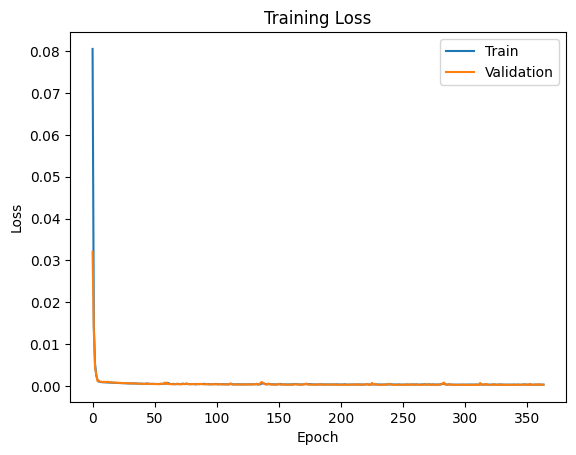

4/4 [==============================] - 1s 5ms/step


In [ ]:
predictions_lb_14day, training_time_lb_14day = parallel_lstm_model(train_scaled, test_data_lb_14day, 14, 96)

(880, 21, 5)
(98, 21, 5)
Epoch 1/500
10/10 [==============================] - 7s 103ms/step - loss: 0.0533 - val_loss: 0.0177
Epoch 2/500
10/10 [==============================] - 0s 15ms/step - loss: 0.0076 - val_loss: 0.0011
Epoch 3/500
10/10 [==============================] - 0s 14ms/step - loss: 0.0029 - val_loss: 0.0011
Epoch 4/500
10/10 [==============================] - 0s 19ms/step - loss: 0.0017 - val_loss: 0.0017
Epoch 5/500
10/10 [==============================] - 0s 19ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 6/500
10/10 [==============================] - 0s 20ms/step - loss: 0.0010 - val_loss: 0.0010
Epoch 7/500
10/10 [==============================] - 0s 22ms/step - loss: 9.0943e-04 - val_loss: 9.4866e-04
Epoch 8/500
10/10 [==============================] - 0s 19ms/step - loss: 8.7657e-04 - val_loss: 8.9321e-04
Epoch 9/500
10/10 [==============================] - 0s 17ms/step - loss: 8.2908e-04 - val_loss: 9.3182e-04
Epoch 10/500
10/10 [==============================

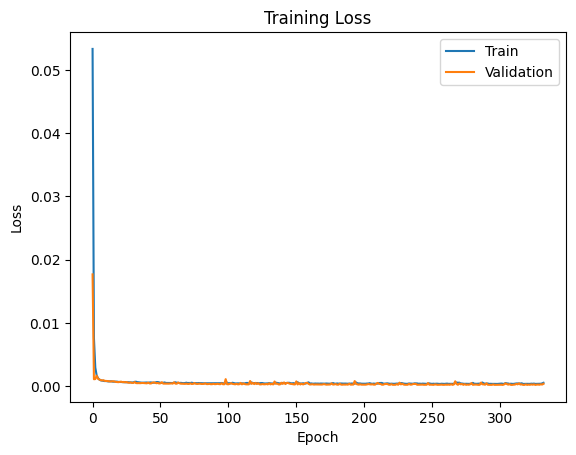

4/4 [==============================] - 1s 5ms/step


In [ ]:
predictions_lb_21day, training_time_lb_21day = parallel_lstm_model(train_scaled, test_data_lb_21day, 21, 96)

In [ ]:
data_visual = data_ORCL.filter(['Date', 'Close'])
data_visual['Date'] = pd.to_datetime(data_visual['Date'])
valid = data_visual[train_size:]

valid['Predictions lb 7 day'] = predictions_lb_7day
valid['Predictions lb 14 day'] = predictions_lb_14day
valid['Predictions lb 21 day'] = predictions_lb_21day

valid

<ipython-input-60-33984e91cc03>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions lb 7 day'] = predictions_lb_7day
<ipython-input-60-33984e91cc03>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions lb 14 day'] = predictions_lb_14day
<ipython-input-60-33984e91cc03>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.

,Date,Close,Predictions lb 7 day,Predictions lb 14 day,Predictions lb 21 day
999,2023-12-19,106.250000,105.103840,105.186983,104.818182
1000,2023-12-20,104.150002,105.670434,105.737221,105.542702
1001,2023-12-21,105.860001,104.308838,103.983160,104.109441
1002,2023-12-22,106.199997,105.355929,104.945284,105.073746
1003,2023-12-26,106.190002,106.113320,105.727518,105.971024
...,...,...,...,...,...
1105,2024-05-22,124.599998,124.616085,124.139821,124.724705
1106,2024-05-23,124.089996,124.240727,123.831815,124.381994
1107,2024-05-24,122.910004,124.585864,123.789902,124.472585
1108,2024-05-28,124.489998,122.717905,122.106680,122.588494


In [ ]:
def calculateAccurary(prediction, close):

  mse = mean_squared_error(close, prediction)
  rmse = np.sqrt(mse)
  mae = mean_absolute_error(close, prediction)
  mape = mean_absolute_percentage_error(close, prediction)
  r2 = r2_score(close, prediction)

  print("RMSE:", round(rmse, 5))
  print("MSE :", round(mse, 5))
  print("MAE :", round(mae, 5))
  print("MAPE:", round(mape, 5))
  print("R^2 :", round(r2, 5))
  print()


print("LSTM Lb 7 day")
print("Training time LSTM:", round(training_time_lb_7day, 2), "seconds", "=", round(training_time_lb_7day/60, 2), "minutes")
calculateAccurary(valid['Predictions lb 7 day'], valid["Close"])

print("LSTM Lb 14 day")
print("Training time LSTM:", round(training_time_lb_14day, 2), "seconds", "=", round(training_time_lb_14day/60, 2), "minutes")
calculateAccurary(valid['Predictions lb 14 day'], valid["Close"])

print("LSTM Lb 21 day")
print("Training time LSTM:", round(training_time_lb_21day, 2), "seconds", "=", round(training_time_lb_21day/60, 2), "minutes")
calculateAccurary(valid['Predictions lb 21 day'], valid["Close"])

LSTM Lb 7 day
Training time LSTM: 49.08 seconds = 0.82 minutes
RMSE: 2.07
MSE : 4.27
MAE : 1.31
MAPE: 0.01
R^2 : 0.92

LSTM Lb 14 day
Training time LSTM: 57.84 seconds = 0.96 minutes
RMSE: 2.05
MSE : 4.19
MAE : 1.32
MAPE: 0.01
R^2 : 0.92

LSTM Lb 21 day
Training time LSTM: 56.53 seconds = 0.94 minutes
RMSE: 2.06
MSE : 4.26
MAE : 1.36
MAPE: 0.01
R^2 : 0.92



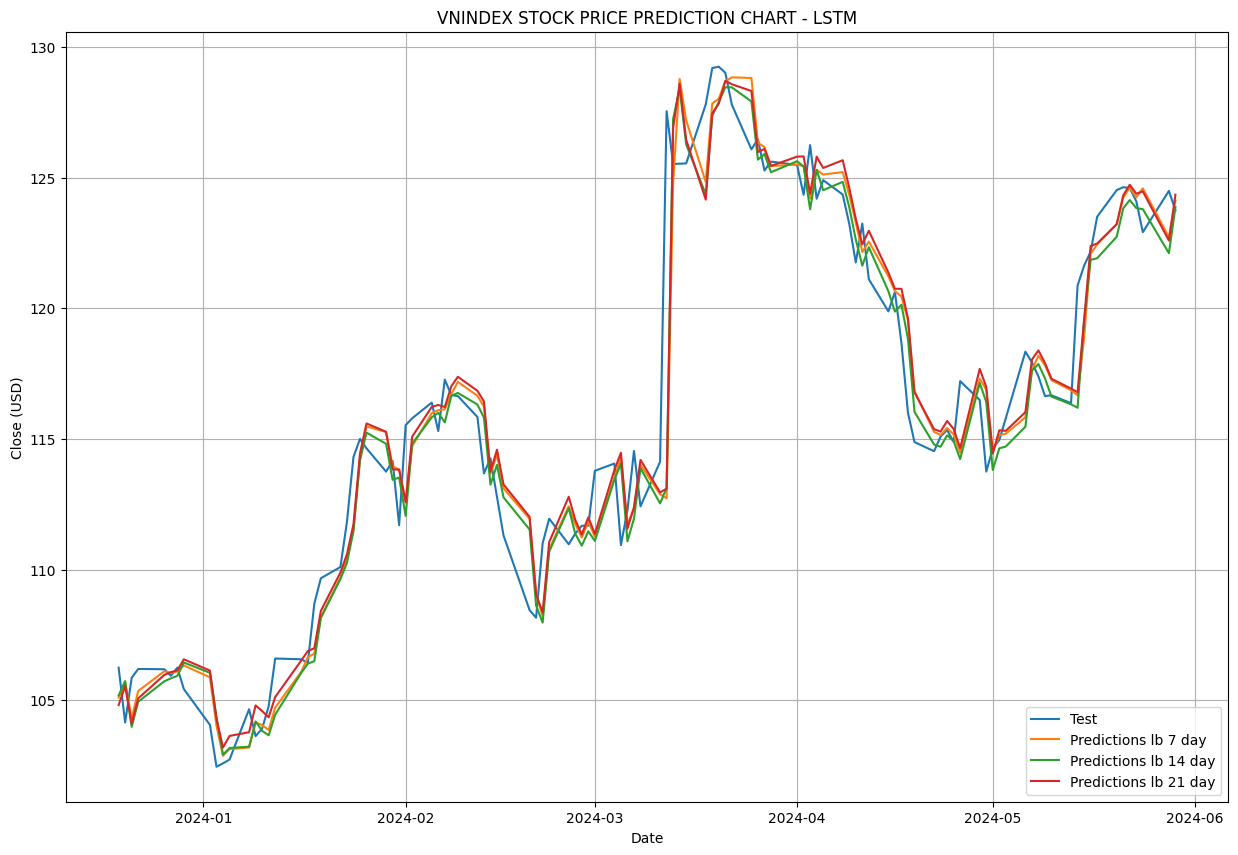

In [ ]:
# Draw a historial of closing price
plt.figure(figsize=(15, 10))

plt.plot(valid['Date'], valid['Close'])
plt.plot(valid['Date'], valid['Pre`dictions lb 7 day'])
plt.plot(valid['Date'], valid['Predictions lb 14 day'])
plt.plot(valid['Date'], valid['Predictions lb 21 day'])
plt.ylabel('Close (USD)', fontsize=16)
plt.ylabel('Close (USD)', fontsize=16)
plt.xlabel('Date', fontsize=16)
plt.title(f"ORCL STOCK PRICE PREDICTION CHART - PARALLEL LSTM-ATTENTION", fontsize=18)
plt.legend(['Actual Closing Price', 'Predicted Closing Price - Lookback  7 days',
            'Predicted Closing Price - Lookback 14 days', 'Predicted Closing Price - Lookback 21 days'], loc='lower right', fontsize=14)
plt.grid(True)
plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)
plt.show()
